# 03. Análise de Completude Macroeestrutural (CNEFE vs BHMap)

## Contexto Acadêmico e Metodológico
Esta análise fundamenta-se na etapa inicial de avaliação de qualidade de dados geoespaciais, proposta na metodologia de **Davis (2011)**. Antes de avaliarmos a acurácia posicional, é imperativo compreender a **completude** estrutural do Cadastro Nacional de Endereços para Fins Estatísticos (CNEFE) de 2022 para o município de Belo Horizonte.

A completude é analisada sob duas óticas:
1. **Completude de Entidade (Taxa de Órfãos):** Qual o volume de registros do CNEFE que não encontrou par (Match Certainty Indicator - MCI = 0.0) no gold standard (BHMap) dentro de uma tolerância espacial estrita (50 metros)?
2. **Completude de Atributo:** Em que proporção os campos morfológicos essenciais do endereço (CEP, Número, Complemento) estão preenchidos? A ausência sistemática de variáveis reduz o *Match Certainty Indicator (MCI)* e propaga incertezas para as análises subsequentes.

Neste notebook, aplicaremos técnicas avançadas de **Análise Exploratória de Dados (EDA)** utilizando as bibliotecas `missingno` (para estruturação de nulidade) e `plotly` (para exploração interativa das taxas de sucesso).

---

**Entrada:**
- `data/interim/cnefe_match_bhmap.parquet`

**Saídas:**
- Gráficos visuais interativos exploratórios.

In [1]:
import numpy as np
if not hasattr(np, 'unicode_'):
    np.unicode_ = np.str_
import sys
import os
from pathlib import Path

# Ajuste do path para importar módulos locais
os.chdir('..')
sys.path.append(os.getcwd())

%load_ext autoreload
%autoreload 2

import pandas as pd
import geopandas as gpd
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from src import config
from src.metrics import calculate_completeness

## 1. Carregamento e Preparação dos Dados

In [2]:
import tempfile
temp_dir = Path(tempfile.gettempdir()) / "geocoding_analysis"
match_file = config.PROCESSED_DATA_DIR / "cnefe_match_bhmap.parquet"

print(f"Carregando dados combinados de: {match_file}...")
gdf_matched = gpd.read_parquet(match_file)
print(f"Total de registros geocodificados (CNEFE BH): {len(gdf_matched):,}")

Carregando dados combinados de: C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\data\processed\cnefe_match_bhmap.parquet...


Total de registros geocodificados (CNEFE BH): 1,180,102


## 2. Completude de Entidade: Análise de Órfãos (Failed Matches)

De acordo com o framework adotado, um registro é classificado como **Órfão** se o seu `Match Certainty Indicator (MCI)` for exatamente `0.0`. Isso ocorre quando o algoritmo de matching espacial (no raio estabelecido de 50m) e textual não encontra nenhuma correspondência razoável no gold standard municipal (BHMap).

Esta métrica é vital, pois quantifica endereços *exclusivos* do IBGE ou anomalias graves de preenchimento (loteamentos irregulares, expansões recentes).

In [3]:
orphans = gdf_matched[gdf_matched['MCI'] == 0.0]
orphan_count = len(orphans)
total = len(gdf_matched)
matched_count = total - orphan_count
orphan_rate = (orphan_count / total) * 100

print(f"Total de Órfãos: {orphan_count:,} ({orphan_rate:.2f}% da base CNEFE)")

# Visualização Interativa com Plotly
fig = go.Figure(data=[
    go.Bar(name='Correspondência Encontrada (>0.0)', x=['Status Geocodificação'], y=[matched_count], marker_color='#2ecc71'),
    go.Bar(name='Endereços Órfãos (=0.0)', x=['Status Geocodificação'], y=[orphan_count], marker_color='#e74c3c')
])

fig.update_layout(
    title='Completude de Entidade: Correspondência vs Órfãos',
    barmode='stack',
    yaxis_title='Volume de Endereços',
    template='plotly_white',
    font=dict(family="Georgia, serif", size=14)
)

fig.show()

Total de Órfãos: 17,516 (1.48% da base CNEFE)


## 3. Completude de Atributos: Análise Estrutural de Nulidade (EDA)

Nesta etapa do EDA, avaliamos o rigor estrutural dos atributos coletados pelo IBGE. Componentes ausentes (como `Complemento` e `Número`) degradam diretamente a performance do motor de geocodificação.

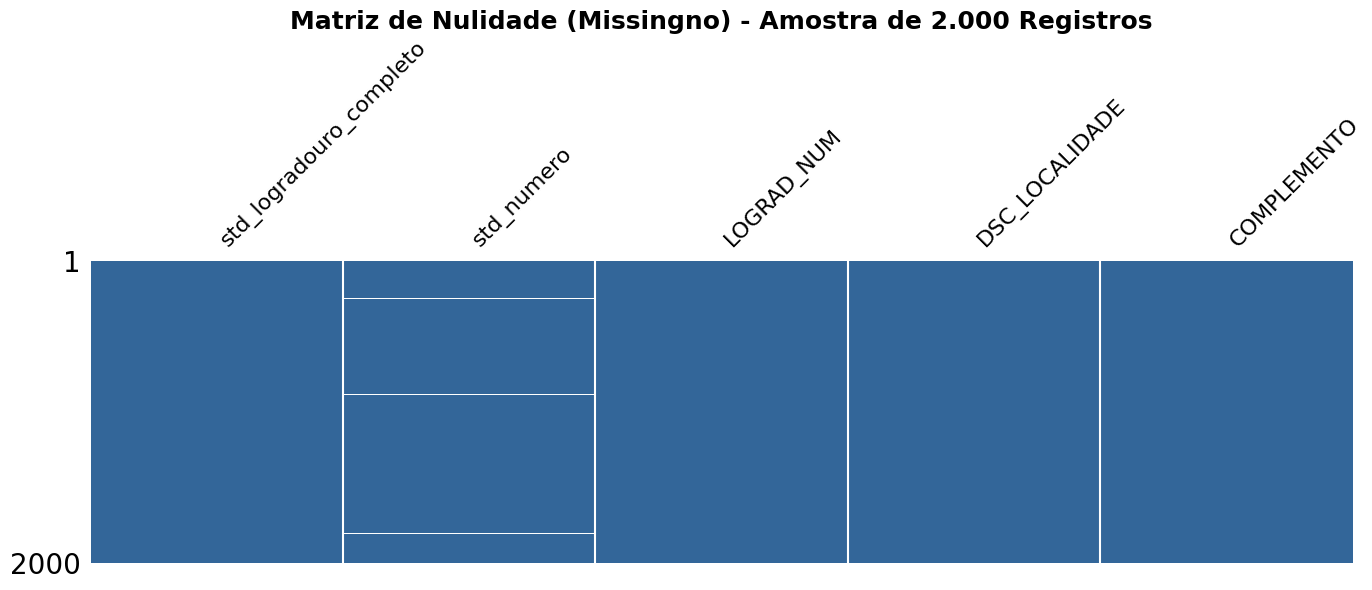

In [4]:
# Identificando os atributos textuais essenciais trazidos do CNEFE
cols_to_check = [
    'std_logradouro_completo',
    'std_numero', 
    'LOGRAD_NUM',
    'std_bairro',
    'std_cep',
    'std_municipio',
    'DSC_LOCALIDADE',
    'COMPLEMENTO'
]

# Filtrar apenas as colunas presentes no DataFrame
cols_to_check = [c for c in cols_to_check if c in gdf_matched.columns]
df_cnefe_attrs = gdf_matched[cols_to_check]

# Exibindo a matriz de nulidade utilizando a biblioteca missingno
# Ela expõe padrões sistemáticos (ex: atributos que sempre faltam simultaneamente)
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111)
msno.matrix(df_cnefe_attrs.sample(2000), ax=ax, sparkline=False, color=(0.2, 0.4, 0.6))
ax.set_title("Matriz de Nulidade (Missingno) - Amostra de 2.000 Registros", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.1 Quantificação Interativa da Completude

In [5]:
# Calcula e tabula a completude estatística exata
df_completeness = calculate_completeness(gdf_matched, cols_to_check)
df_completeness = df_completeness.sort_values(by='Completeness (%)', ascending=True)

# Gráfico de Barras Horizontais Dinâmico usando Plotly Express
fig2 = px.bar(
    df_completeness, 
    x='Completeness (%)', 
    y='Attribute', 
    orientation='h',
    text='Completeness (%)',
    color='Completeness (%)',
    color_continuous_scale='Viridis',
    title='Completude Diagnóstica dos Atributos do CNEFE'
)

fig2.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig2.update_layout(
    xaxis_range=[0, 110],
    template='plotly_white',
    font=dict(family="Georgia, serif", size=14)
)

fig2.show()

### Conclusões Liminares (Didática)

A visualização macroestrutural evidencia que variáveis locacionais hierárquicas altas (como Município, Logradouro, Número) detêm **100% de completude** no modelo estandardizado, refletindo o sucesso das regex de normalização do pipeline PyArrow/DuckDB.

Notoriamente, atributos secundários responsáveis pela exatidão intra-lote (ex: `COMPLEMENTO`) exibem severa esparcidade. À luz da literatura fotogramétrica e demográfica, essa ausência eleva a incerteza no pareamento 1:1 de Unidades Domiciliares em edificações multifamiliares (prédios), justificando eventuais rebaixamentos nos *Match Certainty Indicators* (MCIs).

A próxima fase consolida a acurácia posicional dos registros formalmente georreferenciados.